## Decision Trees（決策樹）

決策樹是分類與迴歸任務中廣泛使用的模型。本質上，它透過學習一系列 **if/else** 問題的層級結構，最終得出決策。

這些問題類似於你在「二十問」遊戲中可能會問的問題。假設你想區分以下四種動物：熊、鷹、企鵝與海豚。你的目標是盡可能使用最少次 **if/else** 提問來找到正確答案。

你可以先問：「這種動物有沒有羽毛？」這個問題能將可能的動物範圍縮小為兩組。如果答案是「是」，你可以接著問：「這種動物是否會飛？」來區分鷹與企鵝；如果答案是「否」（無羽毛），剩餘選項為海豚與熊，此時你可以問：「這種動物是否有鰭？」來區分兩者。

這一系列問題可以用決策樹來表示，如下列範例:

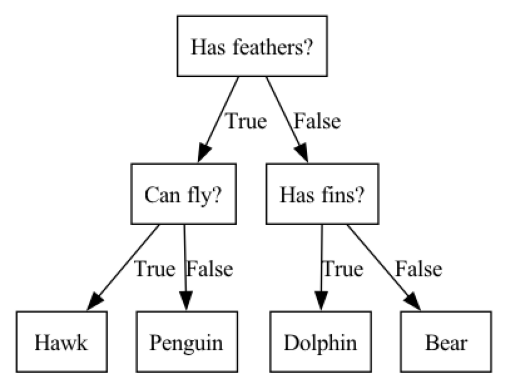

In [2]:
import mglearn

mglearn.plots.plot_animal_tree()

在這張決策樹圖中，每個**節點（Node）**代表一個判定問題，或是包含最終答案的**葉節點（Leaf Node，或稱終端節點）**；節點之間的**邊（Edge）**則連結了對問題的回答以及後續要引導的方向。


以機器學習的術語來說，我們建立了一個分類模型，利用「是否有羽毛」、「是否會飛」與「是否有鰭」這三個特徵（Features），來區分四種動物類別（鷹、企鵝、海豚與熊）。在實際應用中，我們無需人工手動設定這些問答規則，而是透過監督式學習（Supervised Learning）自動從資料中學習並建構出決策樹。

### Building decision trees

讓我們逐步講解如何為下圖 2-23 所示的二維分類資料集建立決策樹。此資料集包含兩個半月形，每個類別包含 75 個資料點。我們將此資料集稱為 two_moons。

學習決策樹意味著學習能夠最快找到正確答案的 if/else 問題序列。在機器學習領域，這些問題被稱為測試（不要與測試集混淆，測試集是我們用來測試模型泛化能力的資料）。通常，資料並非像動物範例那樣以二元（是/否）特徵的形式出現，而是以連續特徵的形式呈現，例如圖 2-23 所示的二維資料集。用於連續資料的測試形式為“特徵 i 是否大於值 a？”

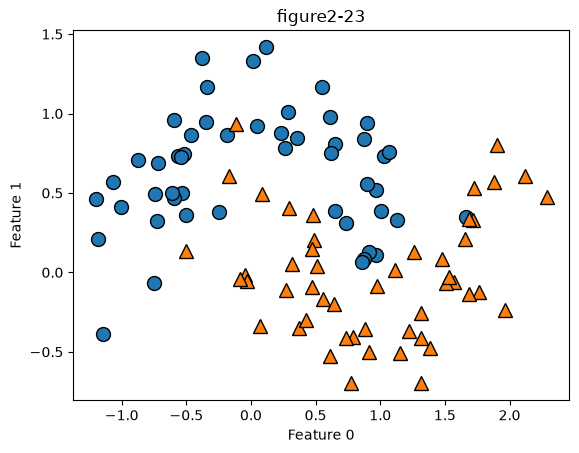

In [4]:
# 圖2-23
from sklearn.datasets import make_moons
import mglearn
import matplotlib.pyplot as plt

# 產生 two_moons 資料集 (與書中圖 2-23 參數一致)
X, y = make_moons(n_samples=100, noise=0.25, random_state=3)

# 使用 mglearn 繪製散佈圖
mglearn.discrete_scatter(X[:, 0], X[:, 1], y)
plt.title("figure2-23")
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.show()

### 決策樹的漸進構建過程與「深度（Depth）」解析

在機器學習中，決策樹的**深度（Depth，或稱 `max_depth`）**指的是**決策樹最多可以連續提出幾層 if/else 問題（即空間分割的次數）**。

如下面的儲存格:透過執行 `mglearn.plots.plot_tree_progressive()`，我們可以看到隨著決策樹深度從 1 逐步增加到 9，特徵空間的切分過程與樹狀結構的變化：

---

#### 1. 深度 `depth = 1`（第一層切分）
* **區域分割（左圖）**：演算法搜尋所有可能的切割點，找到能獲得最大資訊量的測試條件——在 $X[1] = 0.0596$ 處劃出一條水平切分線，將資料集分割為上下兩個區域。
* **樹狀結構（右圖）**：最頂層的**根節點（Root Node）**包含全部 100 個資料點（類別 0 與類別 1 各 50 個，即 `counts = [50, 50]`）。
  * 條件成立（True，小於等於 0.0596，向下）：分至左節點，包含 2 個類別 0 與 32 個類別 1（`counts = [2, 32]`）。
  * 條件不成立（False，大於 0.0596，向上）：分至右節點，包含 48 個類別 0 與 18 個類別 1（`counts = [48, 18]`）。
* 此時樹的深度只有 1，雖然有了初步分類效果，但兩個區域內仍混雜著兩種不同類別的資料點。

---

#### 2. 深度 `depth = 2`（第二層切分）
* **區域分割與結構擴充**：為了提升分類精確度，演算法在上一層劃出的區域中繼續搜尋最佳切分條件（例如對特徵 $X[0]$ 進行縱向切割）。
* 特徵空間被進一步劃分為 4 個獨立區域，樹狀結構也隨之擴充到第 2 層（共包含 4 個葉節點）。

---

#### 3. 深度 `depth = 9`（完全樹與過擬合 Overfitting）
* **遞歸劃分終點**：若不限制樹的深度，遞歸切分過程會持續進行，直到劃分出的每個區域都只包含單一類別的資料點為止。
* **純葉節點（Pure Leaves）**：只包含單一目標類別的葉節點稱為「純葉節點」。在 `depth = 9` 時，所有葉節點皆為純葉節點。
* **過擬合現象（Overfitting）**：觀察邊界圖可以發現決策邊界變得極為曲折複雜，甚至為了包覆單一離群點而切割出狹小分區。這表示模型過度記憶了訓練資料的雜訊與細節，導致泛化能力下降。因此在實用上，通常會限制 `max_depth` 進行剪枝（Pruning）。

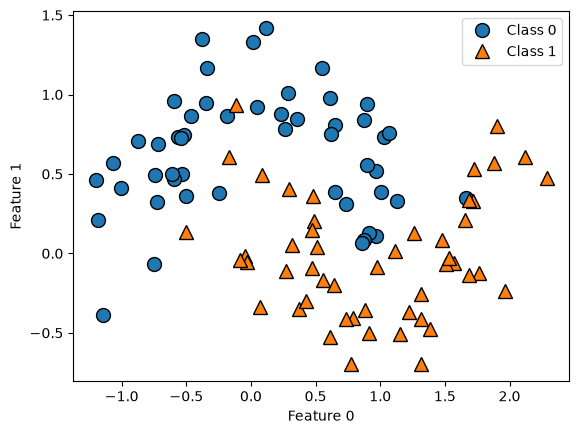

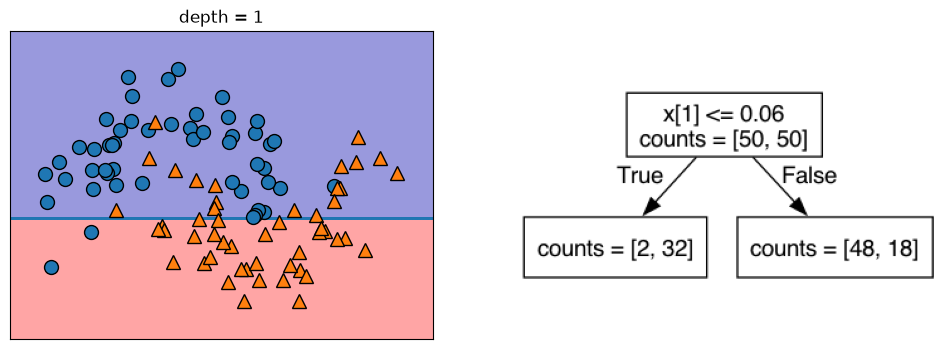

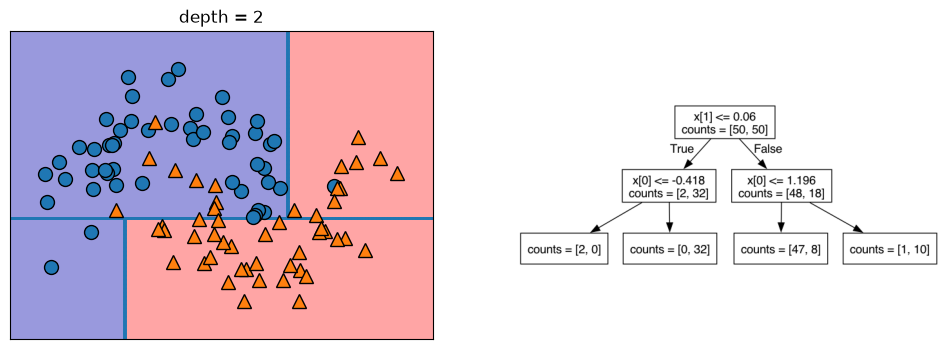

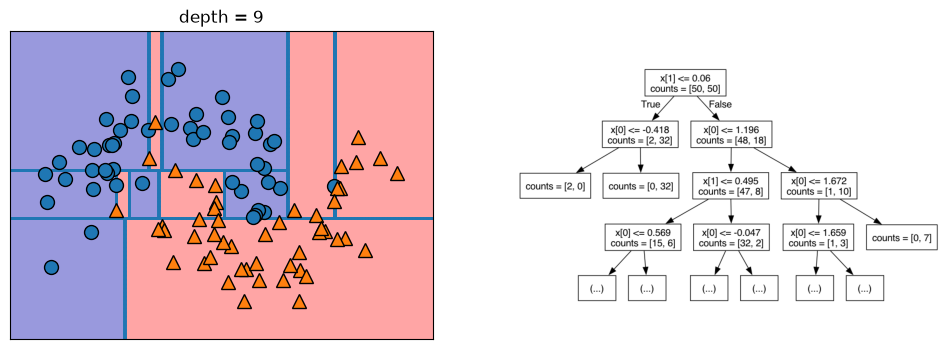

In [5]:
# 圖 2-24: 決策邊界與相對應的樹狀圖 (depth=1, 2, 9 漸進構建過程)
import mglearn
import matplotlib.pyplot as plt

mglearn.plots.plot_tree_progressive()
plt.show()

### 控制決策樹的複雜性（Controlling Complexity of Decision Trees）

通常，如果讓決策樹持續分支直到所有葉節點都成為「純葉節點」，會導致模型結構過於複雜，並產生嚴重的**過擬合（Overfitting）**現象。純葉節點意味著決策樹在訓練集上的準確率高達 100%，因為每個訓練資料點都被完美地劃分到正確的類別區域中。

觀察圖 2-26（`depth = 9`，最右側圖）可以明顯看到過擬合的痕跡：例如在屬於類別 0 的點群中間包覆了一小塊類別 1 的區域；或者在最右側類別 0 的單一資料點周圍切割出狹長的小分區。這種決策邊界過度關注了遠離同類群體的**離群值（Outliers）**，並不符合直覺與實務需求。

為防止過擬合，機器學習中常見兩種**剪枝策略**：
1. **預先剪枝（Pre-pruning）**：在決策樹建構過程中提前停止分支。常見標準包括限制最大深度（`max_depth`）、限制最大葉節點數（`max_leaf_nodes`），或要求節點至少包含一定數量的樣本才允許分割（`min_samples_split`）。
2. **事後剪枝（Post-pruning，或稱剪枝）**：先讓決策樹完全生長，事後再移除或合併資訊量效益較低的節點。

在 `scikit-learn` 中，決策樹分別透過 `DecisionTreeClassifier` 與 `DecisionTreeRegressor` 類別實現。值得注意的是，`scikit-learn` 目前**僅支援預先剪枝（Pre-pruning）**，尚未支援事後剪枝。

接下來，我們以乳癌資料集（Breast Cancer Dataset）為例，詳細觀察預先剪枝對模型品質的影響。首先匯入資料集並拆分為訓練集與測試集；接著先建立一個預設參數的未剪枝模型（讓樹完全生長至純葉節點），並固定 `random_state` 以確保結果可重複：

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

cancer = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, cancer.target, stratify=cancer.target, random_state=42
)
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X_train, y_train)
print(f"訓練集準確率：{tree.score(X_train, y_train):.3f}")
print(f"測試集準確率：{tree.score(X_test, y_test):.3f}")